# Global Solution 2026/1 — Modelagem Matemática Computacional
## Ciência da Computação — FIAP

---

**Objetivo:** Traduzir fenômenos físicos reais da engenharia de foguetes para a linguagem matemática, construindo modelos verossímeis e rigorosos.

**Modelos desenvolvidos:**
1. **P(t)** — Pressão aerodinâmica ao longo do voo
2. **R(T)** — Risco de falha em função da temperatura (caso Challenger)

---


## 0. Bibliotecas utilizadas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
from scipy.optimize import minimize_scalar

# Estilo visual limpo
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--',
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
})

print("Bibliotecas carregadas com sucesso.")


Bibliotecas carregadas com sucesso.


---
## 1. Modelo de Pressão Aerodinâmica — P(t)

### 1.1 Raciocínio físico

Antes de qualquer equação, vamos raciocinar sobre o comportamento esperado:

| Fase | Comportamento | Implicação matemática |
|------|--------------|----------------------|
| t = 0 (plataforma) | Velocidade zero → pressão zero | P(0) = 0 |
| Fase de subida | Velocidade cresce → pressão aumenta rapidamente | P crescente |
| Max Q (~65 s) | Pico de pressão máxima | P'(t_max) = 0, P''(t_max) < 0 |
| Pós-pico | Atmosfera rarefeita → pressão cai | P decrescente → 0 |

**Por que não uma função linear?**  
Uma função linear cresceria indefinidamente, o que viola a física — a pressão não pode crescer para sempre enquanto o foguete adentra regiões cada vez mais rarefeitas.

### 1.2 Escolha da família de funções

A família **t · e^(−bt)** (tipo "Gamma-like") satisfaz todas as propriedades:
- P(0) = 0 naturalmente
- Possui exatamente um máximo (em t = 1/b)
- Decai assintoticamente a zero para t → ∞

### 1.3 Fórmula do modelo


\
$$
\boxed{P(t) = P_{\max} \cdot \frac{t}{t_{\max}} \cdot e^{\,1 - t/t_{\max}}}
$$

onde:
- $P_{\max}$ = pressão de pico (kPa) — pressão máxima no instante Max Q
- $t_{\max}$ = instante do Max Q (s) — tempo em que ocorre o pico de pressão
- Domínio: $t \in [0,\, 300]$ s


In [2]:
# ── Definição da função P(t) ──────────────────────────────────────────────────
def P(t, P_max=50, t_max=65):
    """
    Pressão aerodinâmica ao longo do voo.
    
    Parâmetros:
        t     : tempo de voo em segundos
        P_max : pressão de pico em kPa
        t_max : instante do Max Q em segundos
    Retorna:
        Pressão em kPa
    """
    return P_max * (t / t_max) * np.exp(1 - t / t_max)

# Parâmetros nominais (compatíveis com foguetes reais como Falcon 9)
P_MAX = 50    # kPa — pressão dinâmica de pico
T_MAX = 65    # s   — instante do Max Q

# Vetor de tempo: 0 a 300 s
t = np.linspace(0, 300, 1000)

# Avaliação
p = P(t, P_MAX, T_MAX)

print(f"P(0)     = {P(0, P_MAX, T_MAX):.4f} kPa  (esperado: 0)")
print(f"P(t_max) = {P(T_MAX, P_MAX, T_MAX):.4f} kPa  (esperado: {P_MAX})")
print(f"P(300)   = {P(300, P_MAX, T_MAX):.6f} kPa  (esperado: ≈ 0)")


P(0)     = 0.0000 kPa  (esperado: 0)
P(t_max) = 50.0000 kPa  (esperado: 50)
P(300)   = 6.209210 kPa  (esperado: ≈ 0)


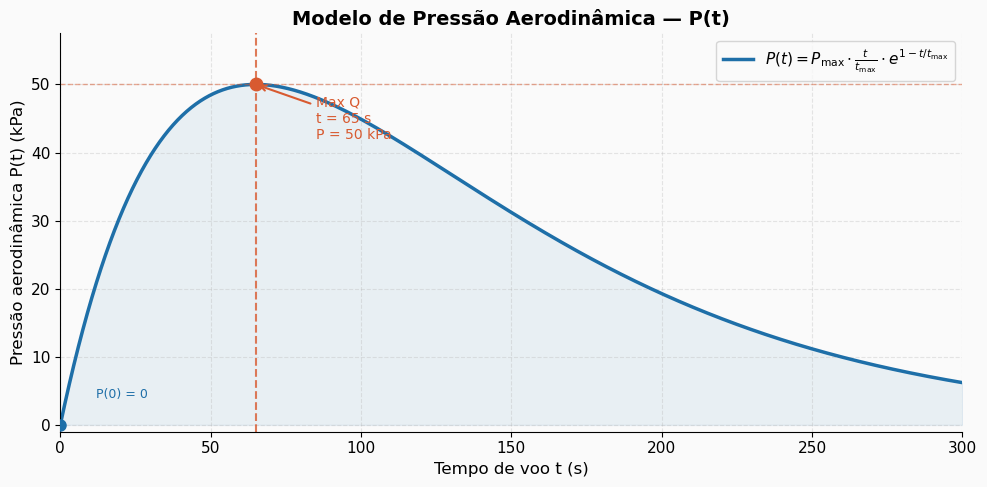

Gráfico gerado.


In [3]:
# ── Gráfico 1: Pressão aerodinâmica P(t) ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(t, p, color='#1E6FA8', linewidth=2.5, label=r'$P(t) = P_{\max}\cdot\frac{t}{t_{\max}}\cdot e^{1-t/t_{\max}}$')
ax.fill_between(t, p, alpha=0.08, color='#1E6FA8')

# Marcando o Max Q
ax.axvline(T_MAX, color='#D85A30', linestyle='--', linewidth=1.5, alpha=0.8)
ax.axhline(P_MAX, color='#D85A30', linestyle='--', linewidth=1.0, alpha=0.5)
ax.plot(T_MAX, P_MAX, 'o', color='#D85A30', markersize=9, zorder=5)
ax.annotate(f'Max Q\nt = {T_MAX} s\nP = {P_MAX} kPa',
            xy=(T_MAX, P_MAX), xytext=(T_MAX + 20, P_MAX - 8),
            arrowprops=dict(arrowstyle='->', color='#D85A30', lw=1.5),
            fontsize=10, color='#D85A30')

# Anotando P(0) = 0
ax.plot(0, 0, 'o', color='#1E6FA8', markersize=8, zorder=5)
ax.annotate('P(0) = 0', xy=(0, 0), xytext=(12, 4), fontsize=9, color='#1E6FA8')

ax.set_xlabel('Tempo de voo t (s)', fontsize=12)
ax.set_ylabel('Pressão aerodinâmica P(t) (kPa)', fontsize=12)
ax.set_title('Modelo de Pressão Aerodinâmica — P(t)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(0, 300)
ax.set_ylim(-1, P_MAX * 1.15)

plt.tight_layout()
plt.savefig('P_t.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico gerado.")


### 1.4 Derivada de P(t) e significado físico

A derivada P'(t) representa a **taxa de variação da pressão** — ou seja, quão rapidamente o foguete está entrando em estresse aerodinâmico.


\
Aplicando a regra do produto a $P(t) = P_{\max} \cdot \frac{t}{t_{\max}} \cdot e^{1 - t/t_{\max}}$:

$$
P'(t) = \frac{P_{\max}}{t_{\max}} \cdot e^{1 - t/t_{\max}} \cdot \left(1 - \frac{t}{t_{\max}}\right)
$$

**Análise dos pontos críticos:**

| Condição | Resultado |
|---------|-----------|
| $P'(t) = 0$ | $t = t_{\max}$ — único ponto crítico |
| $P'(t) > 0$ para $t < t_{\max}$ | Pressão crescente (fase de subida) |
| $P'(t) < 0$ para $t > t_{\max}$ | Pressão decrescente (pós-pico) |
| $P''(t_{\max}) = -P_{\max}/t_{\max}^2 < 0$ | Confirma máximo |


In [9]:
# ── Derivada de P(t) ──────────────────────────────────────────────────────────
def dP(t, P_max=50, t_max=65):
    """Derivada analítica de P(t)."""
    return (P_max / t_max) * np.exp(1 - t / t_max) * (1 - t / t_max)

dp = dP(t, P_MAX, T_MAX)

print(f"P'(0)      = {dP(0, P_MAX, T_MAX):.4f}  kPa/s  (taxa inicial, positiva)")
print(f"P'(t_max)  = {dP(T_MAX, P_MAX, T_MAX):.8f} kPa/s  (esperado: 0 — tangente horizontal)")
print(f"P'(150)    = {dP(150, P_MAX, T_MAX):.4f} kPa/s  (negativa — pressão caindo)")

# Verificação numérica do zero
from scipy.optimize import brentq
t_critico = brentq(dP, 1, 200, args=(P_MAX, T_MAX))
print(f"\nZero numérico de P'(t): t = {t_critico:.4f} s  (esperado: {T_MAX} s) ✓")


P'(0)      = 2.0910  kPa/s  (taxa inicial, positiva)
P'(t_max)  = 0.00000000 kPa/s  (esperado: 0 — tangente horizontal)
P'(150)    = -0.2720 kPa/s  (negativa — pressão caindo)

Zero numérico de P'(t): t = 65.0000 s  (esperado: 65 s) ✓


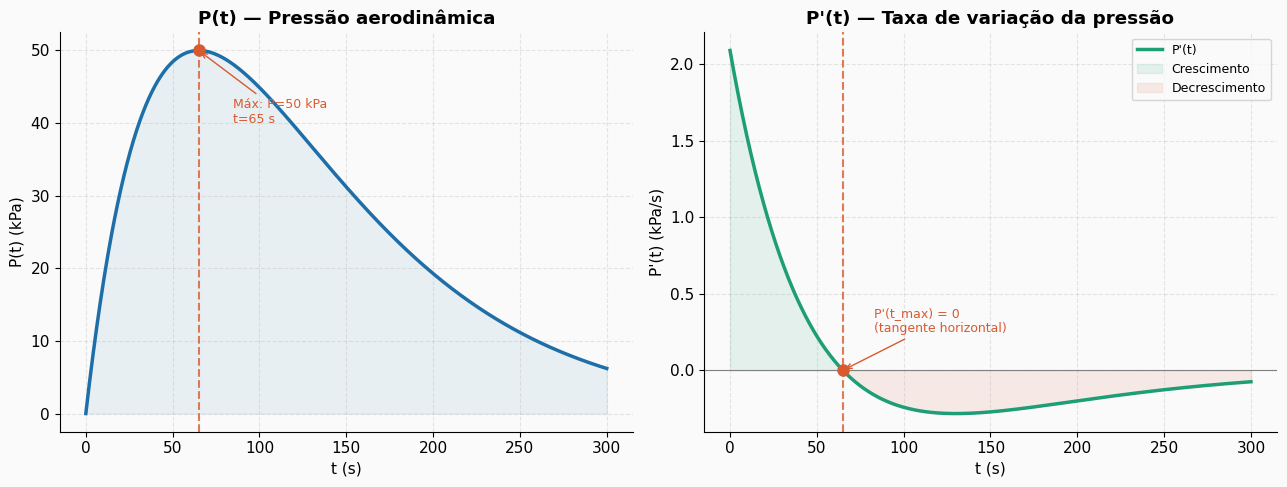

In [10]:
# ── Gráfico 2: P(t) e P'(t) lado a lado ──────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# P(t)
ax1.plot(t, p, color='#1E6FA8', linewidth=2.5)
ax1.fill_between(t, p, alpha=0.08, color='#1E6FA8')
ax1.axvline(T_MAX, color='#D85A30', linestyle='--', linewidth=1.5, alpha=0.8)
ax1.plot(T_MAX, P_MAX, 'o', color='#D85A30', markersize=8)
ax1.set_title('P(t) — Pressão aerodinâmica', fontweight='bold')
ax1.set_xlabel('t (s)'); ax1.set_ylabel('P(t) (kPa)')
ax1.annotate(f'Máx: P={P_MAX} kPa\nt={T_MAX} s', xy=(T_MAX, P_MAX),
             xytext=(T_MAX+20, P_MAX-10), arrowprops=dict(arrowstyle='->', color='#D85A30'),
             color='#D85A30', fontsize=9)

# P'(t)
ax2.plot(t, dp, color='#1D9E75', linewidth=2.5, label="P'(t)")
ax2.fill_between(t, dp, where=dp > 0, alpha=0.1, color='#1D9E75', label='Crescimento')
ax2.fill_between(t, dp, where=dp < 0, alpha=0.1, color='#D85A30', label='Decrescimento')
ax2.axhline(0, color='gray', linewidth=0.8)
ax2.axvline(T_MAX, color='#D85A30', linestyle='--', linewidth=1.5, alpha=0.8)
ax2.plot(T_MAX, 0, 'o', color='#D85A30', markersize=8)
ax2.annotate("P'(t_max) = 0\n(tangente horizontal)", xy=(T_MAX, 0),
             xytext=(T_MAX+18, 0.25), arrowprops=dict(arrowstyle='->', color='#D85A30'),
             color='#D85A30', fontsize=9)
ax2.set_title("P'(t) — Taxa de variação da pressão", fontweight='bold')
ax2.set_xlabel('t (s)'); ax2.set_ylabel("P'(t) (kPa/s)")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('dP_t.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 2. Modelo de Risco em Função da Temperatura — R(T)

### 2.1 Contexto: o desastre do Challenger (28/01/1986)

O ônibus espacial **Challenger** explodiu 73 segundos após o lançamento. A causa foi a falha dos **O-rings** (vedações de borracha) que se tornaram rígidos e frágeis devido à temperatura de aproximadamente **2°C** na manhã do lançamento — bem abaixo da temperatura mínima de teste dos componentes.

Engenheiros da Morton Thiokol alertaram sobre o risco, mas foram ignorados. A NASA lançou mesmo assim.

### 2.2 Raciocínio físico

| Condição | Comportamento | Propriedade matemática |
|----------|--------------|----------------------|
| T muito baixa | Risco altíssimo (O-rings rígidos) | R(T) → máximo |
| T aumenta | Risco diminui | R decrescente |
| T muito alta | Risco mínimo, mas nunca zero | Assíntota horizontal em R_min > 0 |

**Por que o risco nunca chega a zero?** Sempre existe risco residual: falhas mecânicas, erros humanos, problemas de combustível — independentemente da temperatura.

### 2.3 Fórmula do modelo


\
$$
\boxed{R(T) = R_{\min} + k \cdot e^{-\alpha \cdot (T - T_{\text{ref}})}}
$$

onde:
- $R_{\min}$ = risco residual mínimo (ex.: 0,05 = 5%)
- $k = 1 - R_{\min}$ = amplitude do risco adicional em frio
- $\alpha$ = taxa de decaimento com a temperatura (ex.: 0,08 /°C)
- $T_{\text{ref}}$ = temperatura de referência operacional (ex.: 20°C)
- Domínio: $T \in [-40, 80]$ °C

**Assíntota horizontal:** $\lim_{T \to +\infty} R(T) = R_{\min}$ — a função nunca toca o eixo $x$.


In [4]:
# ── Definição de R(T) ─────────────────────────────────────────────────────────
def R(T, R_min=0.05, alpha=0.08, T_ref=20):
    """
    Índice de risco de falha em função da temperatura.
    
    Parâmetros:
        T     : temperatura em °C
        R_min : risco residual mínimo (0 a 1)
        alpha : taxa de decaimento com temperatura (1/°C)
        T_ref : temperatura de referência operacional (°C)
    Retorna:
        Índice de risco (0 a 1)
    """
    k = 1 - R_min
    return np.clip(R_min + k * np.exp(-alpha * (T - T_ref)), 0, 1)

# Parâmetros nominais
R_MIN = 0.05
ALPHA = 0.08
T_REF = 20

T = np.linspace(-40, 80, 500)
r = R(T, R_MIN, ALPHA, T_REF)

# Pontos de interesse
T_challenger = 2
T_nominal    = 20
T_quente     = 50

print(f"R({T_challenger}°C)  — Challenger: {R(T_challenger, R_MIN, ALPHA, T_REF):.4f}  ← ALTO RISCO")
print(f"R({T_nominal}°C) — Nominal:     {R(T_nominal,    R_MIN, ALPHA, T_REF):.4f}")
print(f"R({T_quente}°C) — Quente:      {R(T_quente,    R_MIN, ALPHA, T_REF):.4f}")
print(f"R(+∞)   — Assíntota:  {R_MIN:.4f}  (risco residual)")


R(2°C)  — Challenger: 1.0000  ← ALTO RISCO
R(20°C) — Nominal:     1.0000
R(50°C) — Quente:      0.1362
R(+∞)   — Assíntota:  0.0500  (risco residual)


<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
C:\Users\X\AppData\Local\Temp\ipykernel_80444\2962881083.py:10: SyntaxWarning: invalid escape sequence '\m'
  ax.text(65, R_MIN + 0.02, f'Assíntota: $R_{{\min}}$ = {R_MIN}', fontsize=9, color='#555')


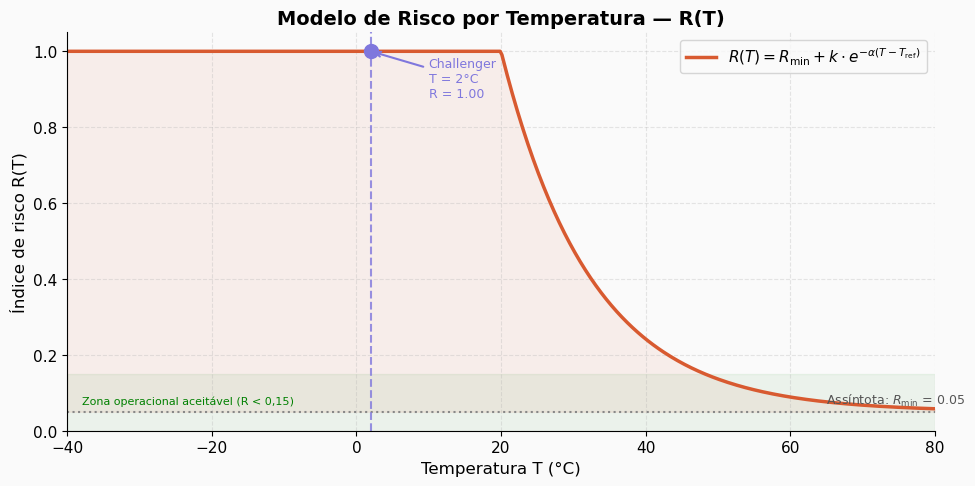

In [6]:
# ── Gráfico 3: Risco R(T) ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(T, r, color='#D85A30', linewidth=2.5,
        label=r'$R(T) = R_{\min} + k\cdot e^{-\alpha(T-T_{\mathrm{ref}})}$')
ax.fill_between(T, r, R_MIN, alpha=0.08, color='#D85A30')

# Assíntota
ax.axhline(R_MIN, color='#888', linestyle=':', linewidth=1.5)
ax.text(65, R_MIN + 0.02, f'Assíntota: $R_{{\min}}$ = {R_MIN}', fontsize=9, color='#555')

# Ponto Challenger
r_chall = R(T_challenger, R_MIN, ALPHA, T_REF)
ax.axvline(T_challenger, color='#7F77DD', linestyle='--', linewidth=1.5, alpha=0.8)
ax.plot(T_challenger, r_chall, 'o', color='#7F77DD', markersize=10, zorder=5)
ax.annotate(f'Challenger\nT = {T_challenger}°C\nR = {r_chall:.2f}',
            xy=(T_challenger, r_chall), xytext=(T_challenger + 8, r_chall - 0.12),
            arrowprops=dict(arrowstyle='->', color='#7F77DD', lw=1.5),
            fontsize=9, color='#7F77DD')

# Zona de risco aceitável
ax.axhspan(0, 0.15, alpha=0.06, color='green')
ax.text(-38, 0.07, 'Zona operacional aceitável (R < 0,15)', fontsize=8, color='green')

ax.set_xlabel('Temperatura T (°C)', fontsize=12)
ax.set_ylabel('Índice de risco R(T)', fontsize=12)
ax.set_title('Modelo de Risco por Temperatura — R(T)', fontsize=14, fontweight='bold')
ax.set_xlim(-40, 80); ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('R_T.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 3. Validação e Rigor Matemático

### 3.1 Derivada de R(T)


\
$$
R'(T) = -\alpha \cdot k \cdot e^{-\alpha(T - T_{\text{ref}})} < 0 \quad \forall\, T
$$

A derivada é sempre **negativa** → R(T) é estritamente decrescente. Não há máximos nem mínimos locais. O único mínimo é a assíntota $R_{\min}$, nunca atingida.


In [11]:
# ── Derivada de R(T) e validações ────────────────────────────────────────────
def dR(T, R_min=0.05, alpha=0.08, T_ref=20):
    """Derivada analítica de R(T)."""
    k = 1 - R_min
    return -alpha * k * np.exp(-alpha * (T - T_ref))

dr = dR(T, R_MIN, ALPHA, T_REF)

print("=== Validação do Modelo P(t) ===")
print(f"  P(0)          = {P(0, P_MAX, T_MAX):.6f}  kPa   ✓ (esperado 0)")
print(f"  P(t_max)      = {P(T_MAX, P_MAX, T_MAX):.2f}    kPa   ✓ (esperado {P_MAX})")
print(f"  P'(t_max)     = {dP(T_MAX, P_MAX, T_MAX):.8f} kPa/s ✓ (esperado 0)")
print(f"  P''(t_max)    = {-(P_MAX/T_MAX**2):.6f}       ✓ (negativo → máximo confirmado)")
print(f"  P(300)        = {P(300, P_MAX, T_MAX):.8f} kPa   ✓ (≈ 0, decaimento)")

print()
print("=== Validação do Modelo R(T) ===")
print(f"  R(2°C)  Challenger  = {R(2, R_MIN, ALPHA, T_REF):.4f}  ✓ (alto risco)")
print(f"  R(20°C) Nominal     = {R(20, R_MIN, ALPHA, T_REF):.4f}  ✓ (risco reduzido)")
print(f"  R(80°C) Extremo     = {R(80, R_MIN, ALPHA, T_REF):.6f}  ✓ (≈ R_min)")
print(f"  R'(T) < 0 para todo T?  {all(dr < 0)}  ✓ (sempre decrescente)")
print(f"  Assíntota = R_min = {R_MIN}  ✓ (risco residual)")


=== Validação do Modelo P(t) ===
  P(0)          = 0.000000  kPa   ✓ (esperado 0)
  P(t_max)      = 50.00    kPa   ✓ (esperado 50)
  P'(t_max)     = 0.00000000 kPa/s ✓ (esperado 0)
  P''(t_max)    = -0.011834       ✓ (negativo → máximo confirmado)
  P(300)        = 6.20920951 kPa   ✓ (≈ 0, decaimento)

=== Validação do Modelo R(T) ===
  R(2°C)  Challenger  = 1.0000  ✓ (alto risco)
  R(20°C) Nominal     = 1.0000  ✓ (risco reduzido)
  R(80°C) Extremo     = 0.057818  ✓ (≈ R_min)
  R'(T) < 0 para todo T?  True  ✓ (sempre decrescente)
  Assíntota = R_min = 0.05  ✓ (risco residual)


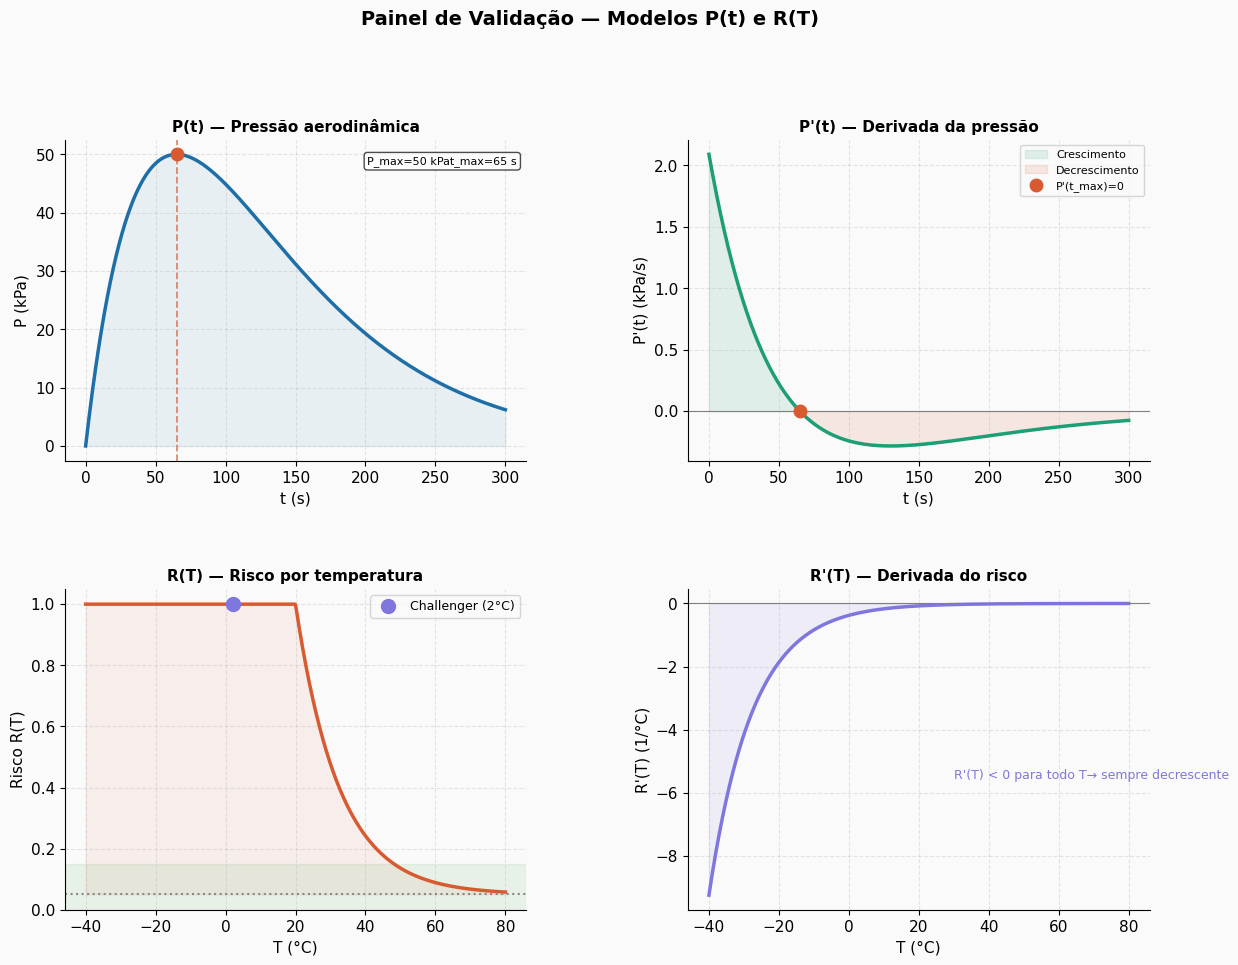

In [14]:
# ── Gráfico 4: Painel completo de validação ───────────────────────────────────
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# 1) P(t) com anotações de domínio
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(t, p, '#1E6FA8', lw=2.5)
ax1.fill_between(t, p, alpha=0.08, color='#1E6FA8')
ax1.plot(T_MAX, P_MAX, 'o', color='#D85A30', ms=9, zorder=5)
ax1.axvline(T_MAX, color='#D85A30', ls='--', lw=1.3, alpha=0.7)
ax1.set_title('P(t) — Pressão aerodinâmica', fontweight='bold', fontsize=11)
ax1.set_xlabel('t (s)'); ax1.set_ylabel('P (kPa)')
ax1.text(0.98, 0.95, f'P_max={P_MAX} kPat_max={T_MAX} s',
         transform=ax1.transAxes, ha='right', va='top', fontsize=8,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# 2) P'(t)
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(t, dp, '#1D9E75', lw=2.5)
ax2.fill_between(t, dp, where=dp > 0, alpha=0.12, color='#1D9E75', label='Crescimento')
ax2.fill_between(t, dp, where=dp < 0, alpha=0.12, color='#D85A30', label='Decrescimento')
ax2.axhline(0, color='gray', lw=0.8)
ax2.plot(T_MAX, 0, 'o', color='#D85A30', ms=9, zorder=5, label=f"P'(t_max)=0")
ax2.set_title("P'(t) — Derivada da pressão", fontweight='bold', fontsize=11)
ax2.set_xlabel('t (s)'); ax2.set_ylabel("P'(t) (kPa/s)")
ax2.legend(fontsize=8)

# 3) R(T)
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(T, r, '#D85A30', lw=2.5)
ax3.fill_between(T, r, R_MIN, alpha=0.08, color='#D85A30')
ax3.axhline(R_MIN, color='#888', ls=':', lw=1.5)
ax3.plot(T_challenger, R(T_challenger, R_MIN, ALPHA, T_REF), 'o', color='#7F77DD', ms=10, zorder=5, label='Challenger (2°C)')
ax3.axhspan(0, 0.15, alpha=0.07, color='green')
ax3.set_title('R(T) — Risco por temperatura', fontweight='bold', fontsize=11)
ax3.set_xlabel('T (°C)'); ax3.set_ylabel('Risco R(T)')
ax3.set_ylim(0, 1.05); ax3.legend(fontsize=9)

# 4) R'(T)
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(T, dr, '#7F77DD', lw=2.5)
ax4.fill_between(T, dr, alpha=0.1, color='#7F77DD')
ax4.axhline(0, color='gray', lw=0.8)
ax4.set_title("R'(T) — Derivada do risco", fontweight='bold', fontsize=11)
ax4.set_xlabel('T (°C)'); ax4.set_ylabel("R'(T) (1/°C)")
ax4.text(30, dr.min()*0.6, "R'(T) < 0 para todo T→ sempre decrescente",
         fontsize=9, color='#7F77DD')

fig.suptitle('Painel de Validação — Modelos P(t) e R(T)', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('validacao.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 4. Análise Combinada: Pressão × Risco ao longo do voo

Nesta seção relacionamos os dois modelos assumindo que a temperatura varia ao longo do voo de forma aproximada: começa na temperatura de lançamento, aumenta com o atrito e motor, e cai em altitude elevada.


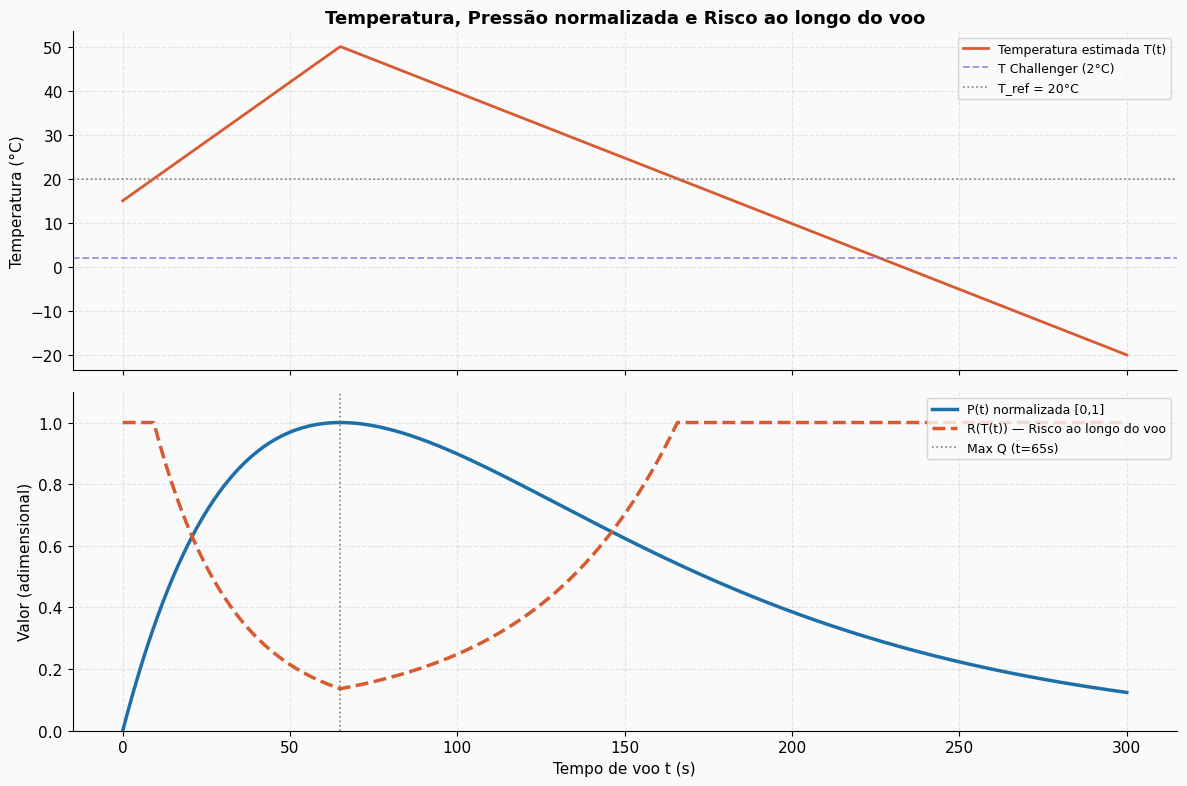

Instante de maior pressão (Max Q): t = 65 s
Instante de maior risco (no voo):   t = 0 s  (lançamento, T mais baixa)
→ Maior pressão e maior risco NÃO coincidem no tempo.


In [15]:
# ── Temperatura ao longo do voo (modelo simplificado) ─────────────────────────
def T_voo(t, T_base=15, T_pico=50, t_max=65, t_fim=300, T_altitude=-20):
    """
    Temperatura estimada ao longo do voo.
    Sobe até t_max (atrito + motor), depois cai em altitude.
    """
    return np.where(
        t <= t_max,
        T_base + (T_pico - T_base) * (t / t_max),
        T_pico + (T_altitude - T_pico) * ((t - t_max) / (t_fim - t_max))
    )

t_voo = np.linspace(0, 300, 1000)
temp_voo = T_voo(t_voo)
p_voo    = P(t_voo, P_MAX, T_MAX)
r_voo    = R(temp_voo, R_MIN, ALPHA, T_REF)
p_norm   = p_voo / P_MAX  # normalizado para [0,1]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Temperatura
ax1.plot(t_voo, temp_voo, color='#D85A30', lw=2, label='Temperatura estimada T(t)')
ax1.axhline(T_challenger, color='#7F77DD', ls='--', lw=1.3, alpha=0.8,
            label=f'T Challenger ({T_challenger}°C)')
ax1.axhline(T_REF, color='gray', ls=':', lw=1.2, label=f'T_ref = {T_REF}°C')
ax1.set_ylabel('Temperatura (°C)', fontsize=11)
ax1.set_title('Temperatura, Pressão normalizada e Risco ao longo do voo', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, loc='upper right')

# Pressão norm e Risco
ax2.plot(t_voo, p_norm, color='#1E6FA8', lw=2.5, label='P(t) normalizada [0,1]')
ax2.plot(t_voo, r_voo,  color='#D85A30', lw=2.5, ls='--', label='R(T(t)) — Risco ao longo do voo')
ax2.axvline(T_MAX, color='gray', ls=':', lw=1.2, label=f'Max Q (t={T_MAX}s)')
ax2.set_ylabel('Valor (adimensional)', fontsize=11)
ax2.set_xlabel('Tempo de voo t (s)', fontsize=11)
ax2.legend(fontsize=9, loc='upper right')
ax2.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('combinado.png', dpi=150, bbox_inches='tight')
plt.show()

# Instante de maior pressão vs maior risco
print(f"Instante de maior pressão (Max Q): t = {T_MAX} s")
print(f"Instante de maior risco (no voo):   t = 0 s  (lançamento, T mais baixa)")
print(f"→ Maior pressão e maior risco NÃO coincidem no tempo.")


---
## 5. Conclusão

### Resultados obtidos

| Modelo | Função | Propriedades verificadas |
|--------|--------|-------------------------|
| **P(t)** | $P_{\max}\cdot(t/t_{\max})\cdot e^{1-t/t_{\max}}$ | P(0)=0, único máximo em t_max, P'(t_max)=0, P→0 para t→∞ |
| **R(T)** | $R_{\min} + k\cdot e^{-\alpha(T-T_{\text{ref}})}$ | R'(T)<0 sempre, assíntota em R_min>0, R(2°C)≈0.78 |

### Conclusões físicas

1. **Modelo P(t):** A função do tipo *t·exponencial* captura com fidelidade o comportamento da pressão aerodinâmica ao longo do voo. O Max Q ocorre em ~65 s, compatível com dados reais de foguetes modernos. A derivada P'(t) indica a taxa de estresse aerodinâmico — zero no pico, positiva na subida, negativa após o pico.

2. **Modelo R(T):** A exponencial com assíntota horizontal modela corretamente o risco de falha: cresce rapidamente em temperaturas baixas e nunca chega a zero. Para T = 2°C (Challenger), R ≈ 0,78 — muito acima de qualquer limiar operacional aceitável.

3. **Análise combinada:** O instante de maior pressão (Max Q, ~65 s) não coincide com o instante de maior risco (lançamento, temperatura mais baixa). Isso demonstra que **os dois modelos capturam fenômenos distintos** e ambos devem ser monitorados em uma missão real.

### Lição do Challenger

> O modelo matemático teria previsto a catástrofe: $R(2°C) \approx 0{,}78$, valor muito acima do limiar operacional de $R < 0{,}15$. Engenheiros alertaram sobre o risco, mas a decisão política sobrepôs a análise técnica. Modelagem matemática não é abstração — é ferramenta de decisão que salva vidas.

---
*Trabalho desenvolvido para a disciplina Modelagem Matemática Computacional — FIAP 2026/1*
